# Food.com Data Exploration

Dieses Notebook analysiert die beiden Rohdateien `RAW_interactions.csv` und `RAW_recipes.csv` als Basis für unser eigenes Recommender-Setup. Der Fokus liegt auf:

- Verstehen der Interaktionen
- Verstehen der Rezept-Metadaten
- Join-Abdeckung zwischen beiden Dateien
- Vorbereitung einer sinnvollen Interaktionsregel für späteres Top-N-Recommendation-Modeling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

interactions_path = "../data/raw/RAW_interactions.csv"
recipes_path = "../data/raw/RAW_recipes.csv"

interactions = pd.read_csv(interactions_path)
recipes = pd.read_csv(recipes_path)

print("Interactions shape:", interactions.shape)
print("Recipes shape:", recipes.shape)

print("\nInteractions columns:")
print(interactions.columns.tolist())

print("\nRecipes columns:")
print(recipes.columns.tolist())

print("\nInteractions head:")
display(interactions.head(3))

print("\nRecipes head:")
display(recipes.head(3))

Interactions shape: (1132367, 5)
Recipes shape: (231637, 12)

Interactions columns:
['user_id', 'recipe_id', 'date', 'rating', 'review']

Recipes columns:
['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients']

Interactions head:


,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for 15 minutes.Added a shake of cayenne and a pinch of salt. Used low fa...
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall evening. Should have doubled it ;)<br/><br/>Second time around, forgo..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not quite a whole package (10oz) of white chips. Great!



Recipes head:


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course', 'main-ingredient', 'cuisine', 'preparation', 'occasion', 'north-ame...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'depending on size of squash , cut into half or fourths', 'remove seeds', ...","autumn is my favorite time of year to cook! this recipe \r\ncan be prepared either spicy or sweet, your choice!\r\nt...","['winter squash', 'mexican seasoning', 'mixed spice', 'honey', 'butter', 'olive oil', 'salt']",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course', 'main-ingredient', 'cuisine', 'preparation', 'occasion', 'north-ame...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough into the bottom and sides of a 12 inch pizza pan', 'bake for 5 minute...",this recipe calls for the crust to be prebaked a bit before adding ingredients. feel free to change sausage to ham o...,"['prepared pizza crust', 'sausage patty', 'eggs', 'milk', 'salt and pepper', 'cheese']",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'main-dish', 'chili', 'crock-pot-slow-cooker', 'dietary', 'equipment', '4-...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add chopped onions to ground beef when almost brown and sautee until wilted', 'a...",this modified version of 'mom's' chili was a hit at our 2004 christmas party. we made an extra large pot to have som...,"['ground beef', 'yellow onions', 'diced tomatoes', 'tomato paste', 'tomato soup', 'rotel tomatoes', 'kidney beans', ...",13


In [2]:
print("Interactions dtypes:")
print(interactions.dtypes)

print("\nRecipes dtypes:")
print(recipes.dtypes)

interactions["date"] = pd.to_datetime(interactions["date"], errors="coerce")
recipes["submitted"] = pd.to_datetime(recipes["submitted"], errors="coerce")

print("\nMissing dates in interactions:", interactions["date"].isna().sum())
print("Missing submitted dates in recipes:", recipes["submitted"].isna().sum())

Interactions dtypes:
user_id      int64
recipe_id    int64
date           str
rating       int64
review         str
dtype: object

Recipes dtypes:
name                str
id                int64
minutes           int64
contributor_id    int64
submitted           str
tags                str
nutrition           str
n_steps           int64
steps               str
description         str
ingredients         str
n_ingredients     int64
dtype: object

Missing dates in interactions: 0
Missing submitted dates in recipes: 0


## 1. Interactions Exploration

Zuerst analysieren wir nur das Event-Log. Diese Datei ist später die Grundlage für den temporal split und für alle Collaborative-Filtering-Modelle.

In [3]:
print("--- BASIC INTERACTION STATS ---")

num_users = interactions["user_id"].nunique()
num_items = interactions["recipe_id"].nunique()
num_interactions = len(interactions)
sparsity = 1 - (num_interactions / (num_users * num_items))

print(f"Users: {num_users:,}")
print(f"Recipes in interactions: {num_items:,}")
print(f"Interactions: {num_interactions:,}")
print(f"Sparsity: {sparsity:.4%}")

print("\nDate range:")
print("Min date:", interactions["date"].min())
print("Max date:", interactions["date"].max())

print("\nRating distribution:")
print(interactions["rating"].value_counts().sort_index())

--- BASIC INTERACTION STATS ---
Users: 226,570
Recipes in interactions: 231,637
Interactions: 1,132,367
Sparsity: 99.9978%

Date range:
Min date: 2000-01-25 00:00:00
Max date: 2018-12-20 00:00:00

Rating distribution:
rating
0     60847
1     12818
2     14123
3     40855
4    187360
5    816364
Name: count, dtype: int64


In [4]:
print("--- USER / ITEM ACTIVITY ---")

user_activity = interactions.groupby("user_id").size()
item_popularity = interactions.groupby("recipe_id").size()

cold_users = (user_activity == 1).sum()
cold_items = (item_popularity == 1).sum()
valid_users_2plus = (user_activity >= 2).sum()

print(f"Cold users (1 interaction): {cold_users:,} ({cold_users / num_users:.2%})")
print(f"Cold items (1 interaction): {cold_items:,} ({cold_items / num_items:.2%})")
print(f"Users with >= 2 interactions: {valid_users_2plus:,} ({valid_users_2plus / num_users:.2%})")

print("\nUser activity quantiles:")
print(user_activity.quantile([0.5, 0.75, 0.9, 0.95, 0.99]))

print("\nItem popularity quantiles:")
print(item_popularity.quantile([0.5, 0.75, 0.9, 0.95, 0.99]))

--- USER / ITEM ACTIVITY ---
Cold users (1 interaction): 166,256 (73.38%)
Cold items (1 interaction): 91,953 (39.70%)
Users with >= 2 interactions: 60,314 (26.62%)

User activity quantiles:
0.50     1.0
0.75     2.0
0.90     5.0
0.95    11.0
0.99    61.0
dtype: float64

Item popularity quantiles:
0.50     2.0
0.75     4.0
0.90     9.0
0.95    15.0
0.99    47.0
dtype: float64


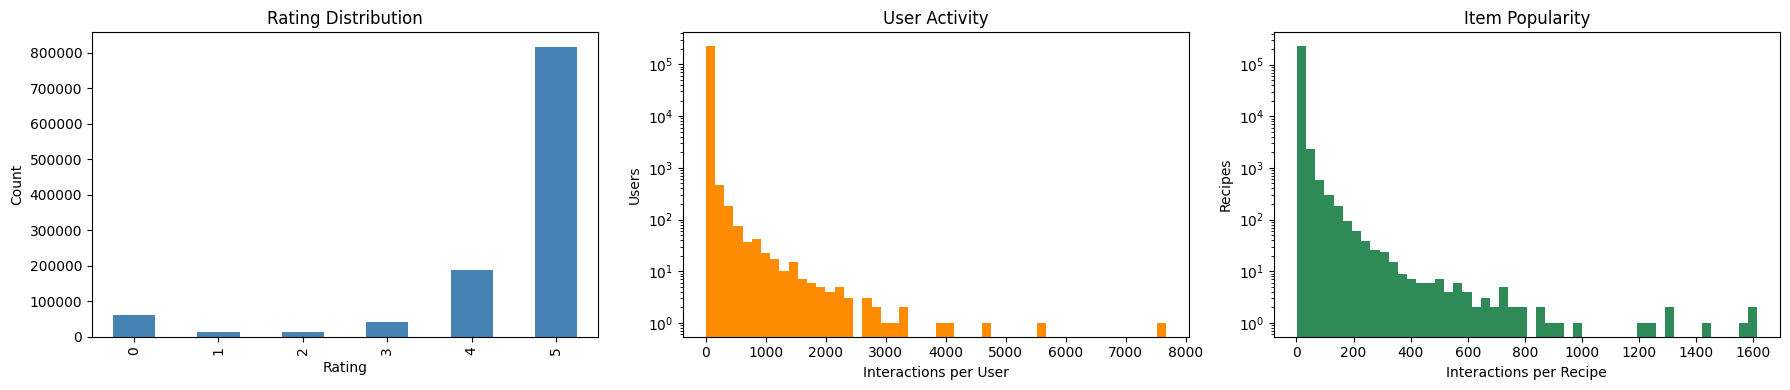

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

interactions["rating"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Rating Distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

axes[1].hist(user_activity, bins=50, color="darkorange")
axes[1].set_title("User Activity")
axes[1].set_xlabel("Interactions per User")
axes[1].set_ylabel("Users")
axes[1].set_yscale("log")

axes[2].hist(item_popularity, bins=50, color="seagreen")
axes[2].set_title("Item Popularity")
axes[2].set_xlabel("Interactions per Recipe")
axes[2].set_ylabel("Recipes")
axes[2].set_yscale("log")

plt.tight_layout()
plt.show()

## 2. Recipes Exploration

Jetzt schauen wir auf die Item-Seite: Welche Metadaten sind vorhanden und für spätere content-based oder hybride Modelle brauchbar?

In [6]:
print("--- RECIPE METADATA OVERVIEW ---")

print("Missing values per column:")
print(recipes.isna().sum())

print("\nNumeric summary:")
display(recipes[["minutes", "n_steps", "n_ingredients"]].describe())

print("Example recipe names:")
display(recipes[["id", "name", "minutes", "n_steps", "n_ingredients"]].head(10))

--- RECIPE METADATA OVERVIEW ---
Missing values per column:
name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description       4979
ingredients          0
n_ingredients        0
dtype: int64

Numeric summary:


,minutes,n_steps,n_ingredients
count,2.316370e+05,231637.000000,231637.000000
mean,9.398546e+03,9.765499,9.051153
std,4.461963e+06,5.995128,3.734796
min,0.000000e+00,0.000000,1.000000
25%,2.000000e+01,6.000000,6.000000
50%,4.000000e+01,9.000000,9.000000
75%,6.500000e+01,12.000000,11.000000
max,2.147484e+09,145.000000,43.000000


Example recipe names:


,id,name,minutes,n_steps,n_ingredients
0,137739,arriba baked winter squash mexican style,55,11,7
1,31490,a bit different breakfast pizza,30,9,6
2,112140,all in the kitchen chili,130,6,13
3,59389,alouette potatoes,45,11,11
4,44061,amish tomato ketchup for canning,190,5,8
5,5289,apple a day milk shake,0,4,4
6,25274,aww marinated olives,15,4,9
7,67888,backyard style barbecued ribs,120,10,22
8,70971,bananas 4 ice cream pie,180,8,6
9,75452,beat this banana bread,70,12,9


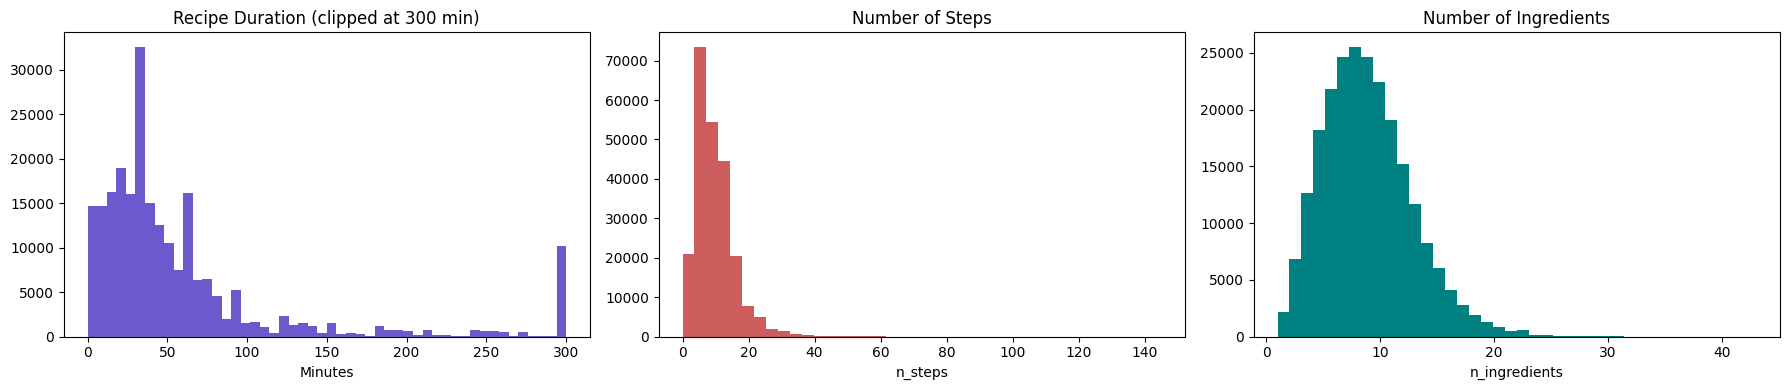

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(recipes["minutes"].clip(upper=300), bins=50, color="slateblue")
axes[0].set_title("Recipe Duration (clipped at 300 min)")
axes[0].set_xlabel("Minutes")

axes[1].hist(recipes["n_steps"], bins=40, color="indianred")
axes[1].set_title("Number of Steps")
axes[1].set_xlabel("n_steps")

axes[2].hist(recipes["n_ingredients"], bins=40, color="teal")
axes[2].set_title("Number of Ingredients")
axes[2].set_xlabel("n_ingredients")

plt.tight_layout()
plt.show()

## 3. Join Check Between Interactions and Recipes

Bevor wir mit Modellierung weitermachen, prüfen wir, wie gut sich Interaktionen und Rezept-Metadaten verbinden lassen.

In [8]:
interaction_recipe_ids = set(interactions["recipe_id"].unique())
metadata_recipe_ids = set(recipes["id"].unique())

matched_ids = interaction_recipe_ids & metadata_recipe_ids
missing_in_recipes = interaction_recipe_ids - metadata_recipe_ids
unused_recipe_metadata = metadata_recipe_ids - interaction_recipe_ids

print("Recipes referenced in interactions:", len(interaction_recipe_ids))
print("Recipes available in metadata:", len(metadata_recipe_ids))
print("Matched recipe IDs:", len(matched_ids))
print("Interaction recipe IDs missing in metadata:", len(missing_in_recipes))
print("Metadata recipes never interacted with:", len(unused_recipe_metadata))

df_model = interactions.merge(
    recipes,
    left_on="recipe_id",
    right_on="id",
    how="inner"
)

print("\nJoined modeling dataframe shape:", df_model.shape)
display(df_model[["user_id", "recipe_id", "date", "rating", "name", "minutes", "n_steps", "n_ingredients"]].head(5))

Recipes referenced in interactions: 231637
Recipes available in metadata: 231637
Matched recipe IDs: 231637
Interaction recipe IDs missing in metadata: 0
Metadata recipes never interacted with: 0

Joined modeling dataframe shape: (1132367, 17)


,user_id,recipe_id,date,rating,name,minutes,n_steps,n_ingredients
0,38094,40893,2003-02-17,4,white bean green chile pepper soup,495,4,9
1,1293707,40893,2011-12-21,5,white bean green chile pepper soup,495,4,9
2,8937,44394,2002-12-01,4,devilicious cookie cake delights,20,5,4
3,126440,85009,2010-02-27,5,baked potato toppings,10,3,13
4,57222,85009,2011-10-01,5,baked potato toppings,10,3,13


## 4. Candidate Interaction Rules

Unser bisheriges Projekt arbeitet mit Top-N-Recommendation und einem positiven Event-Log. Deshalb vergleichen wir hier einfache Regeln, um später eine saubere Modellierungsentscheidung zu treffen.

In [9]:
thresholds = [4, 5]
summary_rows = []

for threshold in thresholds:
    positive_df = interactions[interactions["rating"] >= threshold].copy()
    positive_user_activity = positive_df.groupby("user_id").size()
    positive_item_popularity = positive_df.groupby("recipe_id").size()

    summary_rows.append({
        "rule": f"rating >= {threshold}",
        "interactions": len(positive_df),
        "users": positive_df["user_id"].nunique(),
        "recipes": positive_df["recipe_id"].nunique(),
        "users_with_2plus": int((positive_user_activity >= 2).sum()),
        "cold_items": int((positive_item_popularity == 1).sum())
    })

rule_summary = pd.DataFrame(summary_rows)
display(rule_summary)

print("Recommended starting point: use rating >= 4 as positive feedback for the first recommender experiments.")

,rule,interactions,users,recipes,users_with_2plus,cold_items
0,rating >= 4,1003724,180310,217565,52364,90187
1,rating >= 5,816364,158850,186861,45724,81001


Recommended starting point: use rating >= 4 as positive feedback for the first recommender experiments.


In [10]:
positive_interactions = interactions[interactions["rating"] >= 4].copy()
positive_interactions = positive_interactions.rename(columns={"date": "date_time"})
positive_interactions = positive_interactions.sort_values(["user_id", "date_time"])

positive_user_activity = positive_interactions.groupby("user_id").size()
valid_users = positive_user_activity[positive_user_activity >= 2].index
positive_eval_df = positive_interactions[positive_interactions["user_id"].isin(valid_users)].copy()

print("--- PREVIEW OF MODELING DATASET ---")
print("Positive interactions (rating >= 4):", len(positive_interactions))
print("Users with >= 2 positive interactions:", len(valid_users))
print("Interactions remaining for leave-last-out:", len(positive_eval_df))

display(positive_eval_df.head(5))

--- PREVIEW OF MODELING DATASET ---
Positive interactions (rating >= 4): 1003724
Users with >= 2 positive interactions: 52364
Interactions remaining for leave-last-out: 875778


,user_id,recipe_id,date_time,rating,review
263407,1533,17338,2002-02-19,4,This was very tastey. and was easy to make.
813720,1533,24375,2002-04-23,5,Thanks Bergy these were a hit. I had a meeting at my home with a bunch of teenagers. I tripled the recipe and I neve...
639655,1533,10721,2002-05-02,5,"oh my this is wonderful, I made it for dinner tonight and have alread sampled it..ooops.\r\nOne serving less oh well..."
769521,1533,23891,2002-05-06,5,"This was wonderful, We had it for dinner today, husband told to save this one lol.\r\nThe only thing I added was a l..."
34961,1533,24136,2002-05-20,5,Lennie these have great flavor I served them with the Easy Chutney Chicken Kebabs and a tossed green salad..wonderfu...


## 5. Final Modeling Readiness Check

Bevor wir das Evaluations-Notebook umbauen, prüfen wir noch drei praktische Punkte auf dem finalen positiven Datensatz:

- Lassen sich positive Interaktionen sauber mit den Rezept-Metadaten verbinden?
- Gibt es viele doppelte `user_id` / `recipe_id`-Paare?
- Funktioniert unser Leave-last-out-Setup auf diesem finalen Datensatz sinnvoll?

In [11]:
print("--- JOIN POSITIVE INTERACTIONS WITH RECIPE METADATA ---")

recipes_model = recipes.rename(columns={"id": "recipe_id"}).copy()

model_df = positive_eval_df.merge(
    recipes_model,
    on="recipe_id",
    how="inner"
)

print("Model dataframe shape:", model_df.shape)
print("Unique users:", model_df["user_id"].nunique())
print("Unique recipes:", model_df["recipe_id"].nunique())

missing_recipe_rows = len(positive_eval_df) - len(model_df)
print("Dropped interactions due to missing recipe metadata:", missing_recipe_rows)

display(
    model_df[
        ["user_id", "recipe_id", "date_time", "rating", "name", "minutes", "n_steps", "n_ingredients"]
    ].head(5)
)

--- JOIN POSITIVE INTERACTIONS WITH RECIPE METADATA ---
Model dataframe shape: (875778, 16)
Unique users: 52364
Unique recipes: 206817
Dropped interactions due to missing recipe metadata: 0


,user_id,recipe_id,date_time,rating,name,minutes,n_steps,n_ingredients
0,1533,17338,2002-02-19,4,zucchini and rice casserole,50,10,13
1,1533,24375,2002-04-23,5,costa rican stuffed tortilla,15,6,9
2,1533,10721,2002-05-02,5,orange yogurt cream,40,3,4
3,1533,23891,2002-05-06,5,parmesan fish in the oven,25,7,7
4,1533,24136,2002-05-20,5,fennel mashed potatoes,40,16,5


In [12]:
print("--- DUPLICATE CHECK ---")

duplicate_user_recipe = model_df.duplicated(subset=["user_id", "recipe_id"]).sum()
duplicate_full_rows = model_df.duplicated().sum()

print("Duplicate user-recipe pairs:", duplicate_user_recipe)
print("Fully duplicated rows:", duplicate_full_rows)

if duplicate_user_recipe > 0:
    print("\nExample duplicate user-recipe pairs:")
    display(
        model_df[model_df.duplicated(subset=["user_id", "recipe_id"], keep=False)]
        .sort_values(["user_id", "recipe_id", "date_time"])
        [["user_id", "recipe_id", "date_time", "rating", "name"]]
        .head(10)
    )

--- DUPLICATE CHECK ---
Duplicate user-recipe pairs: 0
Fully duplicated rows: 0


In [13]:
print("--- LEAVE-LAST-OUT PREVIEW ---")

model_df = model_df.sort_values(["user_id", "date_time"])

train_df = model_df.groupby("user_id").head(-1).copy()
test_df = model_df.groupby("user_id").tail(1).copy()

print("Train interactions:", len(train_df))
print("Test interactions:", len(test_df))
print("Train users:", train_df["user_id"].nunique())
print("Test users:", test_df["user_id"].nunique())

sample_user = test_df["user_id"].iloc[0]
user_train_max = train_df.loc[train_df["user_id"] == sample_user, "date_time"].max()
user_test_time = test_df.loc[test_df["user_id"] == sample_user, "date_time"].iloc[0]

print("\nLeakage check")
print("Sample user:", sample_user)
print("Last train timestamp:", user_train_max)
print("Test timestamp:", user_test_time)
print("Strictly later test item:", user_test_time > user_train_max)

--- LEAVE-LAST-OUT PREVIEW ---
Train interactions: 823414
Test interactions: 52364
Train users: 52364
Test users: 52364

Leakage check
Sample user: 1533
Last train timestamp: 2007-09-10 00:00:00
Test timestamp: 2008-03-01 00:00:00
Strictly later test item: True
